# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data
To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**The dataset relates to a total of 17 marketing campaigns coducted from 2008-May to November 2010  during which 79,354 contacts were made by the bank agents , mainly as phone contacts . The offers were about opening long-term fixed deposits with attractive interest rates.**

The dataset however filtered to around 41188 contacts.

During data understanding , we would look into-
1. Understanding missing and incorrect values

2. Figuring out the target variable and its relationship with individual features.

3. Do feature engineering

4. Class Imbalance to avoid model learning from overrepresented class .

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV,StratifiedKFold
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, recall_score,f1_score,RocCurveDisplay,roc_auc_score, \
PrecisionRecallDisplay, precision_score, precision_recall_curve, classification_report, ConfusionMatrixDisplay, confusion_matrix)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
#df = pd.read_csv("/content/sample_data/bank-additional-full.csv", sep = ';')

# Connect to google drive to load the file https://drive.google.com/file/d/1iGUX0jT71AgEqF53lEuO_464rKRkw2qg/view?usp=drive_link
df=pd.read_csv("/content/drive/MyDrive/UCbDatasets/bank-additional-full.csv", sep = ';')


In [7]:
df.head(2)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


The dataset contains the target variable y which seems to be the result of the campaign represented by a boolean yes / no

In [8]:
# Print the percentage
pd.DataFrame(df['y'].value_counts(normalize=True))
# There is class imbalance, we will use SMOTE or class weights on training data before model building.

,proportion
y,
no,0.887346
yes,0.112654


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
**Bank client data**
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')

**Temporal Data**
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). ***Important note: this attribute highly affects the output target
(e.g., if duration=0 then y='no').
Yet, the duration is not known before a call is performed.
Also, after the end of the call y is obviously known.
Thus, this input should only be included for benchmark purposes
and should be discarded if the intention is to have a realistic predictive model.***

**other attributes**
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

#Data Cleaning

In [10]:
# Find duplicates and null values
df.isnull().sum()# Gives no null elements
df.duplicated().sum()# Gives 12 duplicate elements , can be cleaned up
df=df[~df.duplicated()]
df.shape

(41176, 21)

In [11]:
#display all numerical columns
numerical_features=df.select_dtypes(include='number').columns.tolist()
print(numerical_features)
df[df.select_dtypes(include='number').columns].head()

type(numerical_features)

['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


list

In [12]:
print("Descriptive statistics of numerical variables:")
df.describe(include='number').T

Descriptive statistics of numerical variables:


,count,mean,std,min,25%,50%,75%,max
age,41176.0,40.023800,10.420680,17.000,32.000,38.000,47.000,98.000
duration,41176.0,258.315815,259.305321,0.000,102.000,180.000,319.000,4918.000
campaign,41176.0,2.567879,2.770318,1.000,1.000,2.000,3.000,56.000
pdays,41176.0,962.464810,186.937102,0.000,999.000,999.000,999.000,999.000
previous,41176.0,0.173013,0.494964,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41176.0,0.081922,1.570883,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41176.0,93.575720,0.578839,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41176.0,-40.502863,4.627860,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41176.0,3.621293,1.734437,0.634,1.344,4.857,4.961,5.045
nr.employed,41176.0,5167.034870,72.251364,4963.600,5099.100,5191.000,5228.100,5228.100


In [13]:
#Rename the y column to Response
df.rename(columns={'y':'Response'},inplace=True)

# Normalize common yes/no targets to 1/0 if needed
df["Response"].unique()#array(['no', 'yes'], dtype=object)
# Mapy to 0,1
df['Response']=df['Response'].map({'no':0,'yes':1})
df["Response"].unique()

array([0, 1])

In [14]:
X = df.drop(columns=["Response"]).copy()
y = df["Response"].copy()

In [15]:
categorical_features=X.select_dtypes(exclude='number').columns.tolist()
print(categorical_features)
print(type(categorical_features))
df.describe(exclude='number').T

['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
<class 'list'>


,count,unique,top,freq
job,41176,12,admin.,10419
marital,41176,4,married,24921
education,41176,8,university.degree,12164
default,41176,3,no,32577
housing,41176,3,yes,21571
loan,41176,3,no,33938
contact,41176,2,cellular,26135
month,41176,10,may,13767
day_of_week,41176,5,thu,8618
poutcome,41176,3,nonexistent,35551


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Understanding**

The goal is to increase efficiency of directed campaigns for long-term deposit
subscriptions, hence prioritizing resources to probable subscribers  in an efficient manner by reducing the number of contacts.

**Model implementaion**
Compare various classifier models' effectiveness in predictive capability in order to map features to the binary outcome by performing param tuning and cross validation on hold out sets.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

This means that we would only be using customer specific banking information and not the temporal data or economy related data .
Note - duration would lead to data leakage for reaosons as explained in the problem earlier.

We would be following principles for Engineering features as we have the categories for each columns represented below.

In [16]:
df.columns
bank_columns = ['job', 'marital', 'education', 'default', 'housing', 'loan']
for col in bank_columns:
  # print the unique values
  print(f"Feature:{col}",df[col].value_counts())
  #print in bold
  print("-"*100)
  # For education,we may use Ordinal Encoder instead of ohe as it shows progression and higher class category. Illiterate should be 0 whereas unknown for all colums should be imputed .

Feature:job job
admin.           10419
blue-collar       9253
technician        6739
services          3967
management        2924
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Feature:marital marital
married     24921
single      11564
divorced     4611
unknown        80
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
Feature:education education
university.degree      12164
high.school             9512
basic.9y                6045
professional.course     5240
basic.4y                4176
basic.6y                2291
unknown                 1730
illiterate                18
Name: count, dtype: int64
------------------------------------------------------------------------

**Bank client data**
1 - age (numeric)

2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')

3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)

4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')

5 - default: has credit in default? (categorical: 'no','yes','unknown')

6 - housing: has housing loan? (categorical: 'no','yes','unknown')

7 - loan: has personal loan? (categorical: 'no','yes','unknown')

# Feature Engineering

- Feature engineering is the process of transforming raw data into features or variables that a Machine Learning model can effectively use to make predictions.

- These features are the values the model uses as inputs, so creating high-quality features can significantly improve the model's performance.

  - For **categorical features**, it is **mandatory** to transform them before using them in the model. This is because Machine Learning models cannot work directly with text or categories, so they need to be converted into a numerical format (e.g., one-hot encoding or ordinal encoding).

  - For **numerical features**, transformation is not mandatory, but it is recommended. Normalizing or standardizing numerical features can improve the model's accuracy and stability, especially when variables have very different magnitudes of values.

  - **Handling missing values**: Missing values can disrupt model performance. Depending on the data, you may need to impute missing values using methods like mean, median, mode, or interpolation. Alternatively, you can drop rows or columns with missing data if appropriate.

  - **Creating interaction features**: Sometimes, the interaction between two or more features can provide additional predictive power. For example, multiplying or combining features can reveal hidden relationships.

  - **Binning or discretizing features**: For continuous variables, you can create bins or categories (e.g., age groups) to simplify relationships and improve interpretability.

  - **Feature selection**: Removing irrelevant or redundant features can enhance model performance by reducing noise and overfitting.

  - **Dimensionality reduction**: Techniques like Principal Component Analysis (PCA) or Feature Agglomeration can help reduce the number of features while retaining essential information.

  - **Custom feature creation**: Sometimes, domain knowledge can guide you to create new features that better represent the problem at hand. Examples include:
    - Combining date-related features to create a "time of day" or "day of the week" variable.
    - Creating ratios or percentages (e.g., `Fare/FamilySize` to represent how much was paid per person).
    - Encoding geographic features such as latitude/longitude into clusters or distances from specific locations.
    - Generating text-based features, like word counts, sentiment scores, or keyword flags in textual data.
    - Building flags or binary indicators (e.g., "IsSeniorCitizen" for passengers over 60 years old).

  - **Applying domain-specific transformations**: Use domain expertise to create highly specific features that are unique to your dataset or industry (e.g., engineering features based on physical formulas in scientific data, or customer segmentation in marketing data).


In [17]:
df[df["Response"].isnull()].shape
# None of the target values are missing which is good .

(0, 21)

### Visualizations
We include plots for both numeric and categorical variables with clear titles and readable labels.

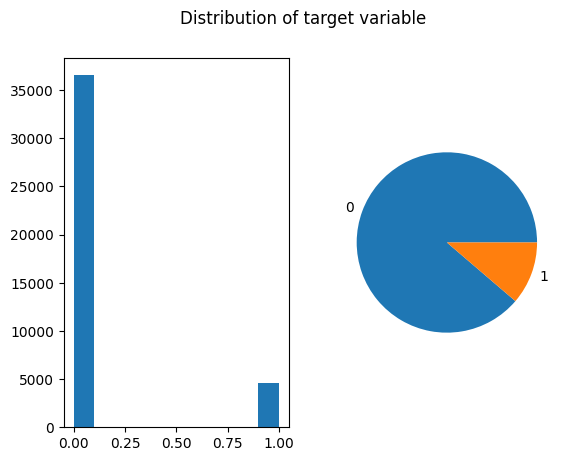

In [18]:
# Plot histogram of target variable y and also the pie chart
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.suptitle('Distribution of target variable')
ax1.hist(df['Response'])
ax2.pie(df['Response'].value_counts(), labels = df['Response'].unique())
plt.show()


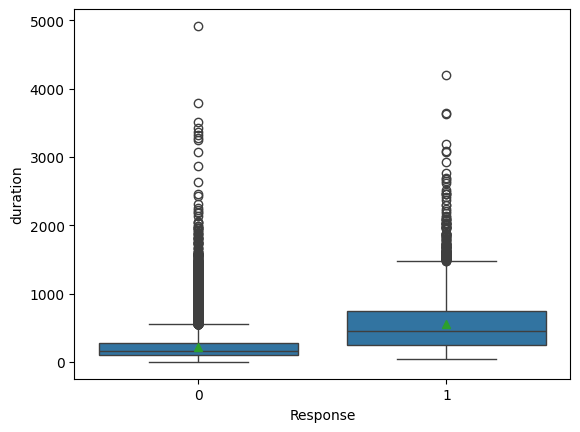

In [19]:
# PLot the duration vs the target variables Response
sns.boxplot(data=df,x='Response', y='duration',showmeans=True)
plt.show()
# Confirmation that lower duration mostly leads to rejection from customer side .

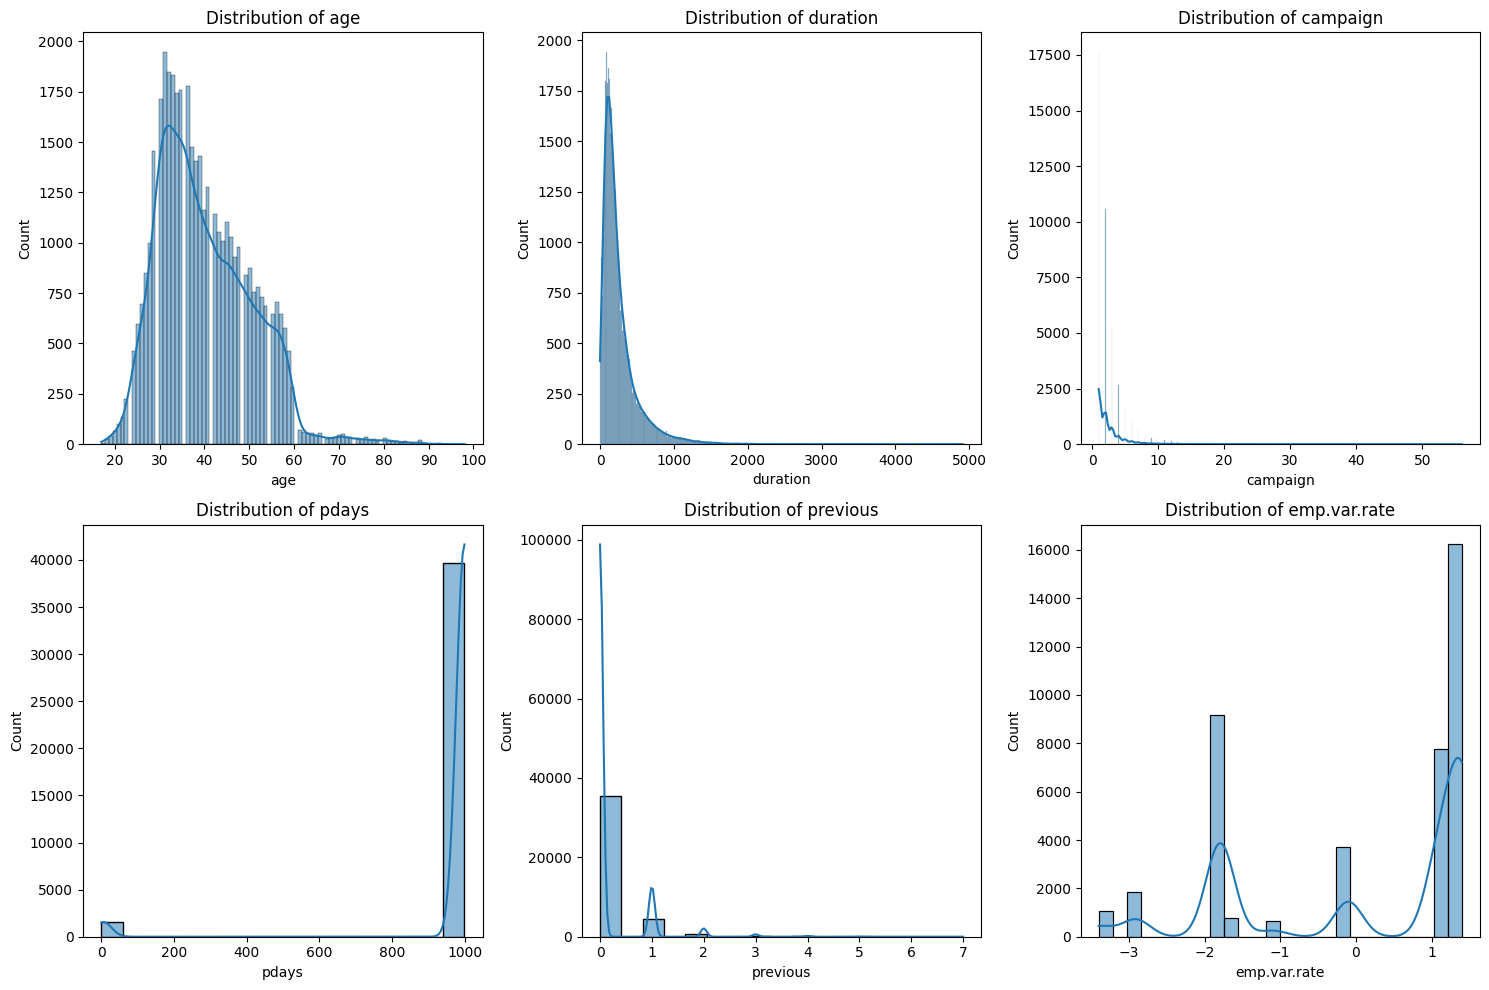

In [20]:
# Do plots of all numerical continuous features against the target columns
num_to_plot = [c for c in numerical_features]
# Plot 15 sub plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten the axes array to iterate over it correctly
for ax, col in zip(axes.flatten(), num_to_plot):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()
# Age is fairly normalized as expected with mean between (30-40).

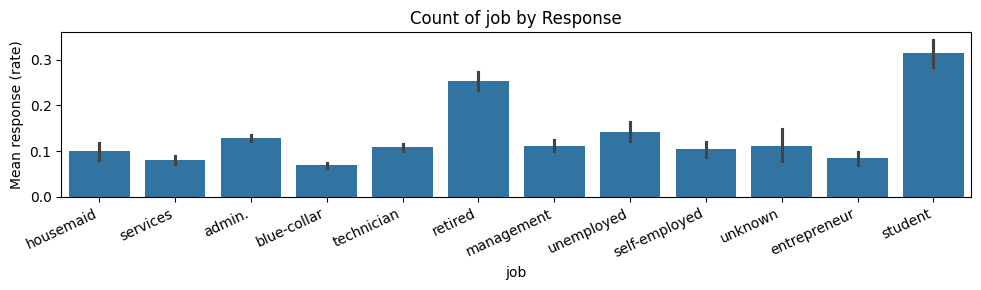

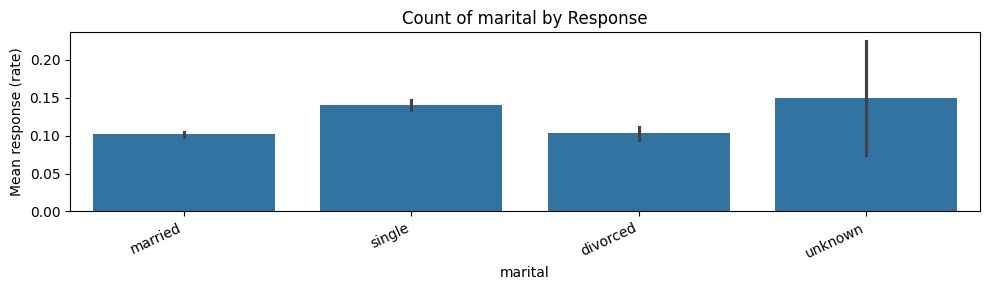

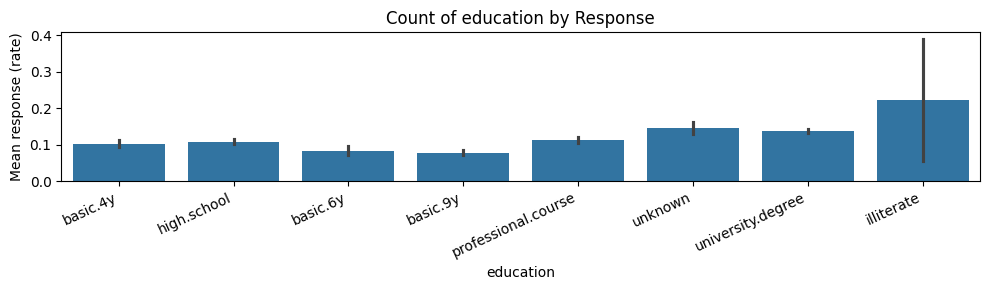

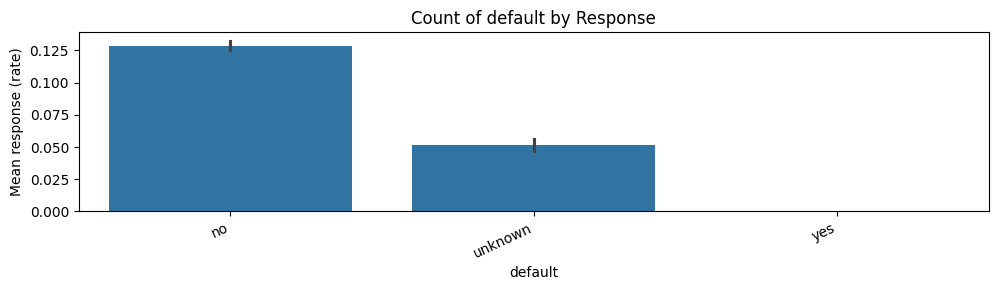

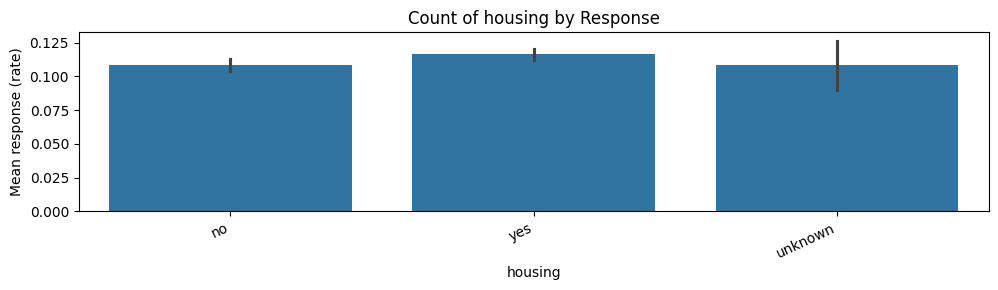

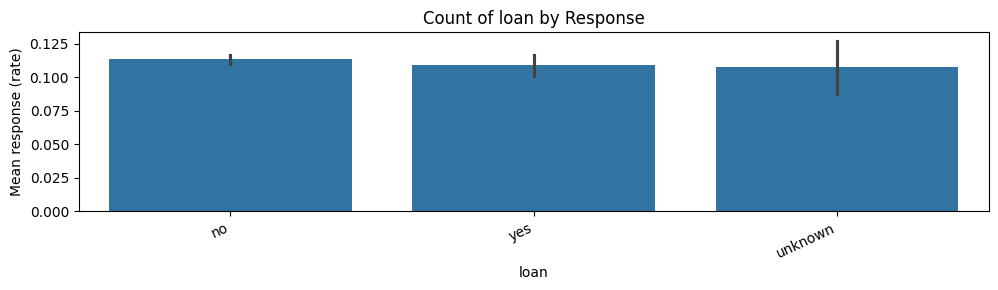

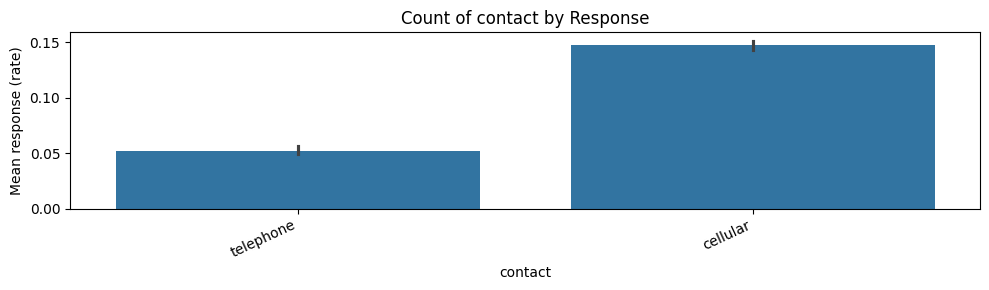

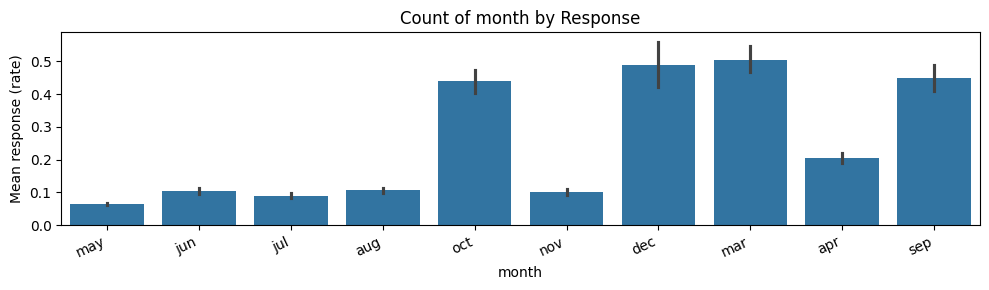

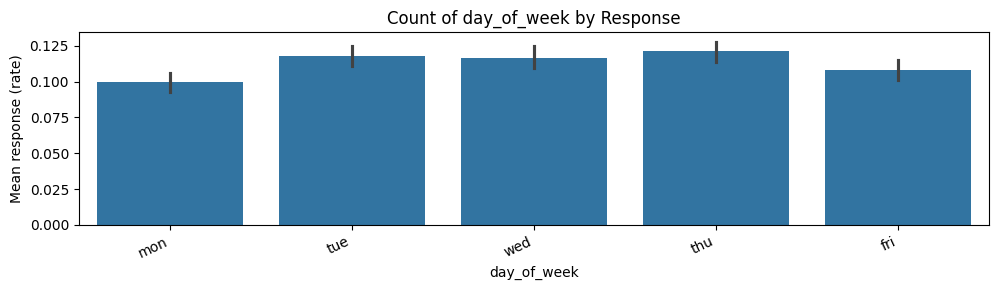

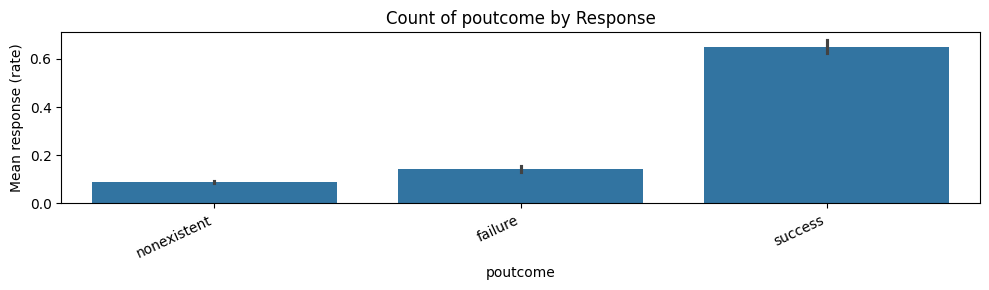

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Do plots  of the individual categorical columns
# Correcting cat_to_plot to be a flat list of column names
# Assuming categorical_features is defined in a previous cell as a list of lists, e.g., [['col1', 'col2']]
# If categorical_features is already a flat list, this modification is still safe as it would just reassign it.
cat_to_plot = categorical_features[0] if isinstance(categorical_features, list) and categorical_features and isinstance(categorical_features[0], list) else categorical_features

for col in cat_to_plot:
    plt.figure(figsize=(10, 3))
    # If Response is numeric 0/1, barplot will show mean response by category
    plt.title(f"Count of {col} by Response")
    tmp = pd.DataFrame({col: X[col], 'Response': y})
    #sns.countplot(data=tmp, x=col, hue='Response')
    # plot barplot for column Age on x axis
    sns.barplot(data=tmp, x=col, y='Response')
    # plt.title(f"Average Response Rate by {col}")
    plt.xticks(rotation=25, ha="right")
    plt.xlabel(col)
    plt.ylabel("Mean response (rate)")
    plt.tight_layout()
    plt.show()

Some key observations- For understanding only
1. Customer is more likely to respond if previous outcome was a success .

2. More likely to respond when they were contacted during mid-week (Wed-Fri) meaning customers are relaxed around the weekends and dont bother .

3. More analysis needed why response rate increases around sept-oct and march . Dec could be due to seasonal holidays .

4. Mobile phone calls are more effective in eliciting response from customers .

5. Customers without loan default are likely to respond more compared to defaulters.


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

# ⚠️ Split Data into Training (Train) and Testing (Test) ⚠️

It is **crucial** to split the data into training and testing sets **BEFORE** performing any feature engineering or training the model.

If we transform the data before splitting, we may inadvertently allow information from the test set to leak into the training data. This leads to overfitting, where the model appears to perform very well on training data but does not truly reflect its performance on new or unseen data.


We would stratify the training and test set both in order to keep the distriubution of the classes of the target variable consistent with the actual data. Otherwise , there is risk for model to learn from data with hardly any minority class hence provising a sub optimal solution.

In [22]:
bank_columns.append('age')
bank_columns

['job', 'marital', 'education', 'default', 'housing', 'loan', 'age']

In [23]:
# Only retain numerical_features which are  in bank_columns
num_columns = [f for f in numerical_features if f in bank_columns]
print(num_columns)

cat_columns = [f for f in categorical_features if f in bank_columns]
print(cat_columns)


['age']
['job', 'marital', 'education', 'default', 'housing', 'loan']


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X[bank_columns], y,test_size=0.2,random_state=42,stratify=y)
# Print the sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (32940, 7)
X_test shape: (8236, 7)


In [25]:
# check if stratify got the desired results
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Response
0    0.887341
1    0.112659
Name: proportion, dtype: float64
Response
0    0.887324
1    0.112676
Name: proportion, dtype: float64


In [26]:
X_train.head(2)

,job,marital,education,default,housing,loan,age
36454,technician,single,professional.course,no,no,no,24
1233,blue-collar,married,professional.course,no,no,no,32


# Balancing your dataset

In classification tasks, checking if data is balanced is crucial because an imbalanced dataset can cause the model to focus on predicting the majority class while ignoring the minority class, leading to biased and poor performance, especially for the underrepresented class. Balancing the data ensures that the model learns equally from all classes, improving its ability to generalize and accurately predict the minority class, which is often critical in applications like fraud detection, medical diagnoses, or churn prediction.

### How to balance your data?
1.  **Resampling Methods**
- Oversampling: Increase the number of samples in the minority class (e.g., using SMOTE or simple duplication).
- Undersampling: Reduce the number of samples in the majority class to match the minority class.

2. **Class Weights**
Many algorithms (e.g., logistic regression, random forest, SVM) allow us to assign higher weights to the minority class, so the model pays more attention to it.


### Key considerations

- Always balance only the **training** set, not the test set.
- Compare model performance with and without balancing.
- Choose the balancing method carefully, as oversampling can lead to overfitting, and undersampling may lose important information.


I decided to use SMOTE as for fraud detection , 32K training records are a reaosnable size for practical model and I do not want to undersize the training space.

**Note If we do not see good results in 1st iteration, we can revisit with calss weights later**

In [27]:
# Import SMOTE library , the standard sklearn pipeline cannot be used here
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer

Using imbalance pipleline for minority oversampling has certain benefits -
1. Avoids data leakage on training model  Even cross validation and grid search would consider SMOTE only for training data and not for validation fold.
2. By putting smote before model fit() func and after preprocessing ensures that the encoders have  handled categorical features already to their encoded values  .
3. When predict is called , it automatically uses the trained model for predictions on unseen test data .

In [28]:
cat_columns

['job', 'marital', 'education', 'default', 'housing', 'loan']

In [29]:
# 1. Define transformers for different column types - we will keep imputers as it is harmless and possibility of unavailable values for future, as a good practice.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))# handling cat values not present due to training split .
])

# 2. Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric_transformer', numeric_transformer,num_columns),
        ('categorical_transformer', categorical_transformer,cat_columns)
    ])

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [30]:
# Build a dummy classifier
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier(strategy='stratified')#(strategy="most_frequent")

# Create the final imblearn Pipeline

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', dummy_clf)
])

# 4. Fit the pipeline

# SMOTE will only be applied during .fit(), not during .predict()
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age']),
                                                 ('categorical_transformer',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', DummyClassifier(strategy='stratified'))])

Baseline Dummy model (test):
Accuracy: 0.49720738222438077
Precision: 0.11484056581155598
recall: 0.5161637931034483
F1: 0.1878799764659737
Confusion matrix:
 [[3616 3692]
 [ 449  479]]
Classification report:
               precision    recall  f1-score   support

           0       0.89      0.49      0.64      7308
           1       0.11      0.52      0.19       928

    accuracy                           0.50      8236
   macro avg       0.50      0.51      0.41      8236
weighted avg       0.80      0.50      0.59      8236

ROC-AUC: 0.49995723864258346


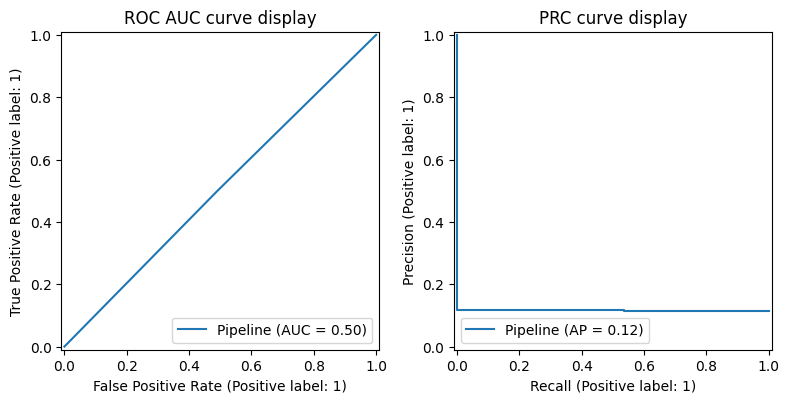

In [31]:
y_dummy_pred = pipeline.predict(X_test)
baseline_proba = pipeline.predict_proba(X_test)[:, 1]
print("Baseline Dummy model (test):")
print("Accuracy:", accuracy_score(y_test, y_dummy_pred))

print("Precision:", precision_score(y_test, y_dummy_pred))
print("recall:", recall_score(y_test, y_dummy_pred))
print("F1:", f1_score(y_test, y_dummy_pred, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, y_dummy_pred))
print("Classification report:\n", classification_report(y_test, y_dummy_pred))
print("ROC-AUC:", roc_auc_score(y_test, baseline_proba))

#Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
axes = axes.flatten()
RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax = ax1)
ax1.set_title("ROC AUC curve display")
PrecisionRecallDisplay.from_estimator(pipeline, X_test, y_test, ax =ax2)
ax2.set_title("PRC curve display")
plt.tight_layout()
plt.show()

The above results indicate a 0.5 score for ROC-AUC which is expected for the dummy classifier with 0 precision and recall because the
dummy model is simply predicting the majority class which is class 0 and hence has no dfiscrimination ability.

Q.What is the baseline performance that our classifier should aim to beat?

**Answer - Our classifiers should aim to beat an F1-score of 0.2 and make it as closer to 1  and have an ROC AUC score above 0.5 which is the random guessing with stratification of 11% minority class**


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [32]:
preprocessor

ColumnTransformer(transformers=[('numeric_transformer',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age']),
                                ('categorical_transformer',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['job', 'marital', 'education', 'default',
                                  'housing', 'loan'])])

In [33]:
lr_model = LogisticRegression(random_state=42, max_iter=2000)
# Create the final imblearn Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', lr_model)
])

lr_pipeline.fit(X_train, y_train)
lr_y_preds=lr_pipeline.predict(X_test)

Logistic Regression model (test):
Accuracy: 0.5882710053423992
Precision: 0.16046319272125723
recall: 0.6271551724137931
F1: 0.25554335894621294
Confusion matrix:
 [[4263 3045]
 [ 346  582]]
Classification report:
               precision    recall  f1-score   support

           0       0.92      0.58      0.72      7308
           1       0.16      0.63      0.26       928

    accuracy                           0.59      8236
   macro avg       0.54      0.61      0.49      8236
weighted avg       0.84      0.59      0.66      8236

ROC-AUC: 0.6515887908621634


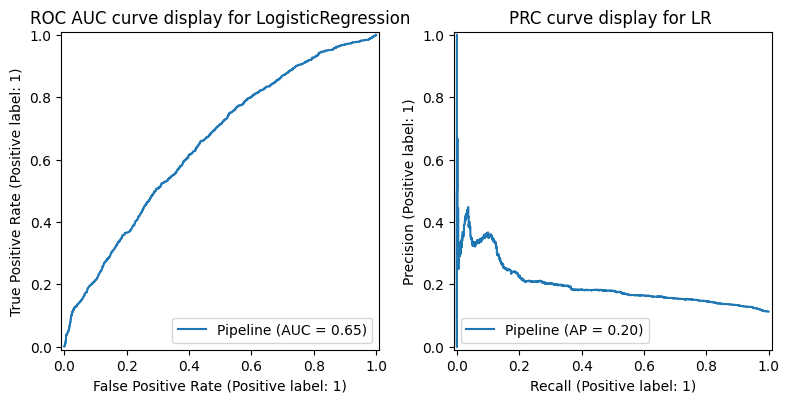

In [34]:
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
print("Logistic Regression model (test):")
print("Accuracy:", accuracy_score(y_test, lr_y_preds))

print("Precision:", precision_score(y_test, lr_y_preds))
print("recall:", recall_score(y_test, lr_y_preds))
print("F1:", f1_score(y_test, lr_y_preds, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_test, lr_y_preds))
print("Classification report:\n", classification_report(y_test, lr_y_preds))
print("ROC-AUC:", roc_auc_score(y_test, lr_proba))

#Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
axes = axes.flatten()
RocCurveDisplay.from_estimator(lr_pipeline, X_test, y_test, ax = ax1)
ax1.set_title("ROC AUC curve display for LogisticRegression")
PrecisionRecallDisplay.from_estimator(lr_pipeline, X_test, y_test, ax =ax2)
ax2.set_title("PRC curve display for LR ")
plt.tight_layout()
plt.show()

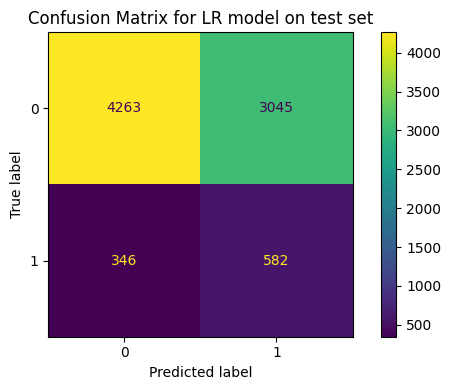

In [35]:
#Create plot
fig, ax = plt.subplots(figsize=(6,4))
ConfusionMatrixDisplay.from_estimator(lr_pipeline, X_test, y_test,ax=ax)
ax.set_title("Confusion Matrix for LR model on test set")
plt.tight_layout()
plt.show()

### Problem 9: Score the Model

What is the accuracy of your model?

**The accuracy on test data is 0.59, which is better than the random classifier that gave 0.51 and hence better ability to discriminate between the 2 classes**

Lets try the same model on training data to cross check the findings.

In [36]:
lr_y_train=lr_pipeline.predict(X_train)
lr_proba=lr_pipeline.predict_proba(X_train)[:,1]
print("Logistic Regression model (train):")
print("Accuracy:", accuracy_score(y_train, lr_y_train))

# Lets do precision , recall , F1 , classification report , matrix and ROC AUC
print("Precision:", precision_score(y_train, lr_y_train))
print("recall:", recall_score(y_train, lr_y_train))
print("F1:", f1_score(y_train, lr_y_train, zero_division=0))
print("Confusion matrix:\n", confusion_matrix(y_train, lr_y_train))
print("Classification report:\n", classification_report(y_train, lr_y_train))
print("ROC-AUC:", roc_auc_score(y_train, lr_proba))


Logistic Regression model (train):
Accuracy: 0.5925925925925926
Precision: 0.16130607688550896
recall: 0.6230126650498518
F1: 0.25626246951895365
Confusion matrix:
 [[17208 12021]
 [ 1399  2312]]
Classification report:
               precision    recall  f1-score   support

           0       0.92      0.59      0.72     29229
           1       0.16      0.62      0.26      3711

    accuracy                           0.59     32940
   macro avg       0.54      0.61      0.49     32940
weighted avg       0.84      0.59      0.67     32940

ROC-AUC: 0.6507895600854657


Macro average refers to the averaging of metrics like precision, recall, or F1 score across all classes, treating each class equally regardless of their support values. This method is useful for understanding the overall performance of a model across all classes but may not accurately reflect the model's performance on the dataset as a whole. It is particularly useful in scenarios where class distributions are imbalanced, as it accounts for the contribution of each class based on their support values.

***Important Observations*** - We see that the scores between training and test sets are similar. This is due to
1. Stratification - It made sure that the model learns and generalizes with similar class distribution of majortiy and minority classes  . Hence , it is able to genralize well on unseen data .

2. SMOTE - THis is a good sign that fixing the class imbalance , the model does not get biased towards the majoruty class and predicts well on the unseen data. Hence, neither overfitting or underfitting even on the test data which has class imbalance.

In [37]:
y_test.value_counts(normalize=True)

,proportion
Response,
0,0.887324
1,0.112676


IMPORTANT POINT
SMOTE is only applied during the fit() method on the X_train and y_train data. When we call lr_pipeline.predict(X_test) or lr_pipeline.predict_proba(X_test), the SMOTE step is bypassed duriing prediction to avoid data leakage.  This is a feature of imblearn pipeline.
Hence , the scores we see for test data are realistic evaluation of our model's performance on unseen, imbalanced data.





### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [38]:
from timeit import default_timer as timer
models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVC': SVC()
}

In [39]:
results =[]
for name, model in models.items():
    start_time = timer()
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    pipeline.fit(X_train, y_train)
    train_time = timer() - start_time

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    # Compute the precision, recall , F1-score and accuracy scores for train split
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1_score = f1_score(y_train, y_train_pred)

    # Compute the precision, recall , F1-score and accuracy scores for test split
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred)
    test_recall = recall_score(y_test, y_test_pred)
    test_f1_score = f1_score(y_test, y_test_pred)

    # Store results
    results.append({
          "Model": name,
          "Train Accuracy": train_accuracy,
          "Train Precision": train_precision,
          "Train Recall": train_recall,
          "Train F1": train_f1_score,
          "Test Accuracy": test_accuracy,
          "Test Precision": test_precision,
          "Test Recall": test_recall,
          "Test F1": test_f1_score,
          "Train Time": train_time
      })

    # Convert results to a DataFrame and display
    # results_df = pd.DataFrame(results).sort_values(by="Test F1", ascending=False)
    # results_df.columns =
    results_df = pd.DataFrame(results)



In [40]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="Test F1", ascending=False)
results_df

,Model,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1,Train Time
0,KNN,0.817881,0.324000,0.567502,0.412496,0.745629,0.170897,0.326509,0.224361,0.719768
1,Decision Tree,0.867668,0.427289,0.513069,0.466267,0.799296,0.190436,0.240302,0.212482,2.513303
2,SVC,0.668427,0.186615,0.578550,0.282203,0.657115,0.170833,0.530172,0.258403,389.751370


We can see that even with these limited features and 30K+ data points , the training time for SVM is taking 4-7 mins(for different runs) as compared to 1-3s for others due to the expensive
Kernel Matrix Computation  in default linear kernel.

We would have to try with rbf and poly kernels during grid search as well.


1.Predictive metrics for all the DM algorithms and CRISP-DM iterations - Plot the table for all clasifiers  

2. Plot the ROC AUC and Lift curves for finding the top deciles for making the campaigns focus on customers most likely to respond to marketing cammpaighns.

### Problem 11: Improving the Model(Using strattified k-fold CV in GridSearch for all models)


Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.

***Also trying different C regularization hyperparamters for LR and kernels for SVM classifier.***

- Adjust your performance metric

In [41]:
models
#add one line for 'LR' : LogisticRegression(max_iter=2000)
models['LR'] = LogisticRegression(max_iter=2000)
# Remove SVM as it is slow , would run it separately
models.pop('SVC')
models

{'KNN': KNeighborsClassifier(),
 'Decision Tree': DecisionTreeClassifier(),
 'LR': LogisticRegression(max_iter=2000)}

I will also use stratified KFold CV along with Gridsearch, SVM seems to take a lot of time hence would run it seprately .

In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

SVM was taking ages to complete and ultimately timed out , hence to make the gs manageable for SVM only , I will reduce the param set for running only on non-default values while still keeping the rbf kernel .

The default values for the SVC classifier's parameters are:
C: The default value for the regularization parameter C is 1.0.
kernel: The default kernel type is 'rbf' (Radial Basis Function).
gamma: The default value for the kernel coefficient gamma is 'scale'.

All of the above were already used in Problem 10 .


In [44]:
param_grids = {
    "LR": {
        "model__C": [0.01, 0.1, 1, 10, 100],  # Regularization strength
        "model__solver": ["liblinear", "lbfgs"]  # Optimization algorithms
    },
     "KNN": {
        "model__n_neighbors": [3, 5, 7, 9],  # Number of neighbors
        "model__weights": ["uniform", "distance"]  # Weighting method
    },
    # "SVC": {
    #     "model__C": [0.1, 1, 10],  # Regularization parameter
    #     "model__kernel": ["rbf", "poly"],  # Kernel type
    #     "model__gamma": ["scale", "auto"]  # Kernel coefficient
    # },
    "Decision Tree": {
        "model__max_depth": [None, 5, 10,15,20],  # Maximum depth of the tree
        "model__min_samples_split": [2, 5, 10] # Minimum samples required to split
    }
}

#We will do SVC seprately as it goes on for ages

In [45]:
models.items()

dict_items([('KNN', KNeighborsClassifier()), ('Decision Tree', DecisionTreeClassifier()), ('LR', LogisticRegression(max_iter=2000))])

In [46]:
# Perform cross validation using grid search , use F1 scoring as this is a classfication problem and we intend to find a balance between precisionand recall.
# Reason is that we want to detect as many potential customers as possible without missing many, while
# also avoiding reaching out unnecessarily to customers in a directedcampaign who are unlikely to opt for subscription.
from timeit import default_timer as timer

best_models = {}
results_cv = []
for name, model in models.items():
    # Include SMOTE in the pipeline for GridSearchCV
    cvpipe = Pipeline(steps=[("preprocess", preprocessor), ("smote", SMOTE(random_state=42)), ("model", model)])
    grid = GridSearchCV(cvpipe, param_grids[name], scoring="f1", cv=cv, n_jobs=-1)## choose F1 as score .
    start_time = timer()
    grid.fit(X_train, y_train)
    train_time_model = timer() - start_time
    best_models[name] = grid.best_estimator_
    # Store results
    results_cv.append({"model": f"Tuned {name}", "best_f1_cv": grid.best_score_, "best_params": grid.best_params_, "Train Time": train_time_model})

train_time_total = timer() - start_time

results_cv_df = pd.DataFrame(results_cv).sort_values("best_f1_cv", ascending=False).reset_index(drop=True)
results_cv_df

,model,best_f1_cv,best_params,Train Time
0,Tuned Decision Tree,0.257345,"{'model__max_depth': 5, 'model__min_samples_sp...",72.839874
1,Tuned LR,0.251937,"{'model__C': 0.01, 'model__solver': 'liblinear'}",32.911679
2,Tuned KNN,0.232167,"{'model__n_neighbors': 9, 'model__weights': 'u...",536.734858


In [47]:
results_cv_df

,model,best_f1_cv,best_params,Train Time
0,Tuned Decision Tree,0.257345,"{'model__max_depth': 5, 'model__min_samples_sp...",72.839874
1,Tuned LR,0.251937,"{'model__C': 0.01, 'model__solver': 'liblinear'}",32.911679
2,Tuned KNN,0.232167,"{'model__n_neighbors': 9, 'model__weights': 'u...",536.734858


The lower F1-scores repreent the inherent characteristic of the problem definition. By intentionally excluding highly predictive features like duration, poutcome, campaign, contact, and the economic indicators, we are reducing the predictive power of the model.

Such a constrained feature set naturally limits the predictive power of any model, leading to F1-scores that are lower than what we might have achieved with a richer dataset. An F1-score around 0.25 (which is significantly better than random) is still better than the random classifier (though stratified).

The best we can do is to use unseen X_test to assess the predictive ability of the model.

In [51]:
svm_grid_default_param = {
    "SVC": {
        "model__C": [1],  # Exploring values around the default (1.0), excluding default
        "model__kernel": ["rbf"],  # Keeping rbf for now to manage runtime, as poly is very slow at higher degrees. Will revisit if results not optimum.
        "model__gamma": ["scale"]  # Exploring alternative gamma values, excluding default 'scale' which is already used
    }
}

# Repeat for SVM
cvpipe = Pipeline(steps=[("preprocess", preprocessor), ("smote", SMOTE(random_state=42)), ("model", SVC())])
gridsvc = GridSearchCV(cvpipe, svm_grid_default_param["SVC"], scoring="f1", cv=cv, n_jobs=-1)## choose F1 as score .
start_time = timer()
gridsvc.fit(X_train, y_train)
train_time_model = timer() - start_time
best_models["SVC"] = gridsvc.best_estimator_

svm_results_cv=list()
svm_results_cv.append({"model": f"Tuned SVC", "best_f1_cv": gridsvc.best_score_, "best_params": gridsvc.best_params_, "Train Time": train_time_model})
svm_results_cv

In [49]:
param_grid_svm = {
    "SVC": {
        "model__C": [0.1, 10],
        "model__kernel": ["rbf"],
        "model__gamma": ["scale"]
    }
}

In [52]:
# Repeat for SVM (Run on v5e-1 TPU for faster processing)
cvpipe = Pipeline(steps=[("preprocess", preprocessor), ("smote", SMOTE(random_state=42)), ("model", SVC())])
gridsvc = GridSearchCV(cvpipe, param_grid_svm["SVC"], scoring="f1", cv=cv, n_jobs=-1)## choose F1 as score .
start_time = timer()
gridsvc.fit(X_train, y_train)
train_time_model = timer() - start_time
best_models["SVC"] = grid.best_estimator_
results_cv.append({"model": f"Tuned SVC", "best_f1_cv": gridsvc.best_score_, "best_params": gridsvc.best_params_, "Train Time": train_time_model})
results_cv

[{'model': 'Tuned KNN',
  'best_f1_cv': np.float64(0.23216698053898482),
  'best_params': {'model__n_neighbors': 9, 'model__weights': 'uniform'},
  'Train Time': 536.734857575},
 {'model': 'Tuned Decision Tree',
  'best_f1_cv': np.float64(0.2573454530070683),
  'best_params': {'model__max_depth': 5, 'model__min_samples_split': 5},
  'Train Time': 72.83987398699992},
 {'model': 'Tuned LR',
  'best_f1_cv': np.float64(0.25193679693775267),
  'best_params': {'model__C': 0.01, 'model__solver': 'liblinear'},
  'Train Time': 32.91167902899997},
 {'model': 'Tuned SVC',
  'best_f1_cv': np.float64(0.2548115483124104),
  'best_params': {'model__C': 0.1,
   'model__gamma': 'scale',
   'model__kernel': 'rbf'},
  'Train Time': 2731.1295539110006}]

Saved the results for SVC in case we need to run the notebook again and the training times out.
[{'model': 'Tuned KNN',
  'best_f1_cv': np.float64(0.23216698053898482),
  'best_params': {'model__n_neighbors': 9, 'model__weights': 'uniform'},
  'Train Time': 536.734857575},
 {'model': 'Tuned Decision Tree',
  'best_f1_cv': np.float64(0.2573454530070683),
  'best_params': {'model__max_depth': 5, 'model__min_samples_split': 5},
  'Train Time': 72.83987398699992},
 {'model': 'Tuned LR',
  'best_f1_cv': np.float64(0.25193679693775267),
  'best_params': {'model__C': 0.01, 'model__solver': 'liblinear'},
  'Train Time': 32.91167902899997},
 {'model': 'Tuned SVC',
  'best_f1_cv': np.float64(0.2548115483124104),
  'best_params': {'model__C': 0.1,
   'model__gamma': 'scale',
   'model__kernel': 'rbf'},
  'Train Time': 2731.1295539110006}]

### Cross-validation comparison plot

Predict_proba probailities for top 500-100 people identification for targeted marketing campaign.



##### Questions

### 12. Insights and Interpretations of results for the best classifier model

In [ ]:
import shap
# Use SHAP's LinearExplainer for logistic regression
explainer = shap.LinearExplainer(best_models[''],X_train)

# Compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


The lower F1-scores aren't due to a 'mistake' in feature engineering  but rather an inherent characteristic of the problem as defined. By intentionally excluding highly predictive features like duration, poutcome, campaign, contact, and the economic indicators, we are reducing the predictive power of the model.

Such a constrained feature set naturally limits the predictive power of any model, leading to F1-scores that are lower than what we might have achieved with a richer dataset. An F1-score around 0.25 (which is significantly better than random) is still better than the random classifier (though stratified).